In [1]:
%pip install -q statsbombpy
import sys
if 'google.colab' in sys.modules:
  from google.colab import data_table
  data_table.DataTable.max_columns = 92

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

# downloading the events takes a few minutes, so they are saved to a cache file
# and read from there on later runs (a few seconds)
# in Colab the cache goes to Google Drive, otherwise it is lost when the session ends
FORCE_DOWNLOAD = False  # set to True to download the data from StatsBomb again
if 'google.colab' in sys.modules:
  from google.colab import drive
  drive.mount('/content/drive')
  cache_dir = '/content/drive/MyDrive/statsbomb_cache'
else:
  cache_dir = 'statsbomb_cache'
os.makedirs(cache_dir, exist_ok=True)
cache_file = os.path.join(cache_dir, 'events_wc2018_wc2022.parquet')

if os.path.exists(cache_file) and not FORCE_DOWNLOAD:
  events = pd.read_parquet(cache_file)
  print(f'Loaded events from cache: {cache_file}')
else:
  from statsbombpy import sb
  # FIFA World Cup 2018 (season_id=3) and 2022 (season_id=106)
  matches_2018 = sb.matches(competition_id=43, season_id=3)
  matches_2022 = sb.matches(competition_id=43, season_id=106)
  matches = pd.concat([matches_2018, matches_2022])
  all_events = []
  for match_id in matches['match_id'].tolist():
    match_events = sb.events(match_id = match_id)
    match_events = match_events.dropna(subset = ['player'])
    all_events.append(match_events)
  events = pd.concat(all_events)
  events.to_parquet(cache_file)
  print(f'Downloaded events and saved them to: {cache_file}')

# some players are spelled differently in 2018 and 2022 (e.g. Phil Foden / Philip Foden),
# so each player_id gets a single name (the most frequent one)
player_names = events.groupby('player_id')['player'].agg(lambda names: names.value_counts().index[0])
events['player'] = events['player_id'].map(player_names)
events['substitution_replacement'] = (
    events['substitution_replacement_id'].map(player_names)
    .fillna(events['substitution_replacement'])
)

Loaded events from cache: statsbomb_cache/events_wc2018_wc2022.parquet


In [3]:
# count the relevant actions for each player
relevant_actions = [
    'Pass', 'Shot', 'Duel', 'Clearance', 'Interception',
    'Foul Committed', 'Dribble', 'Block', 'Pressure',
    'Foul Won', 'Dispossessed', 'Ball Recovery', 'Goal Keeper'
]
action_events = events[events['type'].isin(relevant_actions)]
action_counts = pd.get_dummies(action_events['type'], dtype = int)
player_actions = pd.concat([action_events[['player_id', 'player']], action_counts], axis=1)
player_stats = player_actions.groupby(['player_id', 'player']).sum().reset_index()
#display(player_stats.sort_values(by=["Dribble"]))

In [4]:
# add derived stats (crosses, tackles, xG, xA, pass length, shot distance)
import numpy as np
crosses = events[(events['type'] == 'Pass') & (events['pass_cross'] == True)]
total_crosses = crosses.groupby(['player_id', 'player']).size().reset_index(name='Cross')

tackles = events[(events['type'] == 'Duel') & (events['duel_type'] == 'Tackle')]
total_tackles = tackles.groupby(['player_id', 'player']).size().reset_index(name='Tackle')

shots = events[events['type'] == 'Shot'].copy()
player_xg = shots.groupby(['player_id', 'player'])['shot_statsbomb_xg'].sum().reset_index()
player_xg.rename(columns={'shot_statsbomb_xg': 'xG'}, inplace=True)

# xA = xG of the shot that a pass assisted
key_passes = events[(events['type'] == 'Pass') & (events['pass_assisted_shot_id'].notnull())].copy()
shot_xg = shots[['id', 'shot_statsbomb_xg']].rename(columns={
    'id': 'shot_id',
    'shot_statsbomb_xg': 'xA_value'
})
key_passes = key_passes.merge(shot_xg, left_on='pass_assisted_shot_id', right_on='shot_id', how='left')

player_xa = key_passes.groupby(['player_id', 'player'])['xA_value'].sum().reset_index()
player_xa.rename(columns={'xA_value': 'xA'}, inplace=True)

passes = events[events['type'] == 'Pass'].copy()
pass_length = passes.groupby(['player_id', 'player'])['pass_length'].mean().reset_index()
pass_length.rename(columns={'pass_length': 'avg_pass_length'}, inplace=True)

located_shots = shots.dropna(subset=['location']).copy()
coordinates = pd.DataFrame(located_shots['location'].tolist(), index=located_shots.index)
located_shots['X'] = coordinates[0]
located_shots['Y'] = coordinates[1]
# the goal is at (120, 40) on StatsBomb's 120x80 pitch
located_shots['shot_distance'] = np.sqrt((120 - located_shots['X'])**2 + (40 - located_shots['Y'])**2)
shot_distance = located_shots.groupby(['player_id', 'player'])['shot_distance'].mean().reset_index()
shot_distance.rename(columns={'shot_distance': 'avg_shot_distance'}, inplace=True)


player_stats = player_stats.merge(total_crosses, on=['player_id', 'player'], how='left')
player_stats = player_stats.merge(total_tackles, on=['player_id', 'player'], how='left')
player_stats = player_stats.merge(player_xg, on=['player_id', 'player'], how='left')
player_stats = player_stats.merge(player_xa, on=['player_id', 'player'], how='left')
player_stats = player_stats.merge(pass_length, on=['player_id', 'player'], how='left')
player_stats = player_stats.merge(shot_distance, on=['player_id', 'player'], how='left')

# missing values table
missing_count = player_stats.isna().sum()
missing_percent = player_stats.isna().sum() / len(player_stats)
missing_values = pd.concat([missing_count, missing_percent], axis = 1, keys = ['Missing values', 'Percent'])
missing_values['Percent'] = missing_values['Percent'].map('{:.2%}'.format)
print(missing_values)

# where a player has no such actions, use 0
player_stats = player_stats.fillna(0)

                   Missing values Percent
player_id                       0   0.00%
player                          0   0.00%
Ball Recovery                   0   0.00%
Block                           0   0.00%
Clearance                       0   0.00%
Dispossessed                    0   0.00%
Dribble                         0   0.00%
Duel                            0   0.00%
Foul Committed                  0   0.00%
Foul Won                        0   0.00%
Goal Keeper                     0   0.00%
Interception                    0   0.00%
Pass                            0   0.00%
Pressure                        0   0.00%
Shot                            0   0.00%
Cross                         453  41.56%
Tackle                        284  26.06%
xG                            364  33.39%
xA                            444  40.73%
avg_pass_length                 5   0.46%
avg_shot_distance             364  33.39%


In [5]:
# minutes played by each player
minutes = events.dropna(subset = ['player'])[['match_id', 'player_id', 'player']].drop_duplicates()
match_length = events.groupby('match_id')['minute'].max().reset_index()
match_length.rename(columns={'minute': 'match_length'}, inplace=True)
minutes = minutes.merge(match_length, on = 'match_id', how = 'left')
substitutions = events[events['type'] == 'Substitution']

subbed_on = substitutions[['match_id', 'substitution_replacement', 'minute']].rename(
    columns={'substitution_replacement': 'player', 'minute': 'minute_on'}
)

subbed_off = substitutions[['match_id', 'player', 'minute']].rename(
    columns={'minute': 'minute_off'}
)
minutes = minutes.merge(subbed_on, on=['match_id', 'player'], how='left')
minutes['minute_on'] = minutes['minute_on'].fillna(0)
minutes = minutes.merge(subbed_off, on=['match_id', 'player'], how='left')
minutes['minute_off'] = minutes['minute_off'].fillna(minutes['match_length'])
minutes['minutes_played'] = minutes['minute_off'] - minutes['minute_on']
total_minutes = minutes.groupby(['player_id', 'player'])['minutes_played'].sum().reset_index()
#display(total_minutes.sort_values(by = ['player']))

In [6]:
# per 90 minutes normalisation, keeping only players with at least 90 minutes
if 'minutes_played' not in player_stats.columns:
  player_stats = player_stats.merge(total_minutes, on=['player_id', 'player'], how='left')
filtered_stats = player_stats[player_stats['minutes_played'] >= 90].copy()
p90_actions = [
    'Pass', 'Shot', 'Duel', 'Clearance', 'Interception',
    'Foul Committed', 'Dribble', 'Block', 'Pressure',
    'Foul Won', 'Dispossessed', 'Ball Recovery',
    'Cross', 'Tackle', 'xG', 'xA', 'Goal Keeper'
]
for action in p90_actions:
  p90_name = f"{action}_p90"
  filtered_stats[p90_name] = (
            (filtered_stats[action] / filtered_stats['minutes_played']) * 90
        ).round(2)
#display(filtered_stats.sort_values(by=['Pass_p90']))

In [7]:
# separate per 90 table
p90_columns = [col for col in filtered_stats.columns if 'p90' in col]
p90_table = filtered_stats[['player', 'minutes_played', 'player_id', 'avg_pass_length', 'avg_shot_distance'] + p90_columns]
#display(p90_table.sort_values(by=['Pass_p90']))

In [8]:
# main position of each player (the one they played most often)
from sklearn.preprocessing import LabelEncoder
position_events = events.dropna(subset = ['player', 'position'])
positions = position_events.groupby(['player_id', 'player', 'position']).size().reset_index(name = 'count')
positions = positions.sort_values(by = ['player_id', 'count'], ascending = [True, False])
main_positions = positions.groupby(['player_id', 'player']).first().reset_index()
main_positions = main_positions.drop(columns = ['count'])

# one player only has the position "Substitute", so it is set by hand
main_positions.loc[main_positions['player'] == 'Predrag Rajković', 'position'] = 'Goalkeeper'

# the first version used 4 classes (goalkeeper / defender / midfielder / forward) and scored ~0.78,
# but full-backs play more like midfielders than like centre-backs, so they are now separate
position_groups = {
    'Goalkeeper': 'Goalkeeper',

    'Center Back': 'Centre-back', 'Left Center Back': 'Centre-back', 'Right Center Back': 'Centre-back',

    'Left Back': 'Full-back', 'Right Back': 'Full-back',
    'Left Wing Back': 'Full-back', 'Right Wing Back': 'Full-back',

    'Center Defensive Midfield': 'Central Midfielder', 'Center Midfield': 'Central Midfielder',
    'Left Defensive Midfield': 'Central Midfielder', 'Right Defensive Midfield': 'Central Midfielder',

    'Left Midfield': 'Attacking Midfielder', 'Right Midfield': 'Attacking Midfielder',
    'Center Attacking Midfield': 'Attacking Midfielder',
    'Left Attacking Midfield': 'Attacking Midfielder', 'Right Attacking Midfield': 'Attacking Midfielder',
    'Secondary Striker': 'Attacking Midfielder',
    'Left Wing': 'Attacking Midfielder', 'Right Wing': 'Attacking Midfielder',

    'Center Forward': 'Striker', 'Left Center Forward': 'Attacking Midfielder', 'Right Center Forward': 'Attacking Midfielder',

}


main_positions['target_position'] = main_positions['position'].map(position_groups).fillna('Central Midfielder')

dataset_final = p90_table.merge(main_positions[['player_id', 'player', 'target_position']], on=['player_id', 'player'], how='inner')
dataset_final['Defensive_Work_Ratio'] = (dataset_final['Tackle_p90'] + dataset_final['Interception_p90'] + dataset_final['Ball Recovery_p90']) / (dataset_final['Pass_p90'] + 1)
dataset_final['xG_to_xA_Ratio'] = dataset_final['xG_p90'] / (dataset_final['xA_p90'] + 0.01)
dataset_final['Touches_per_Shot'] = (dataset_final['Pass_p90'] + dataset_final['Dribble_p90'] + dataset_final['Duel_p90']) / (dataset_final['Shot_p90'] + 1)
# each player must appear only once (names are unified in the loading cell)
assert not dataset_final['player_id'].duplicated().any()

# encode the positions
encoder = LabelEncoder()
dataset_final['encoded_position'] = encoder.fit_transform(dataset_final['target_position'])

display(dataset_final.sort_values(by = 'Pass_p90'))

,player,minutes_played,player_id,avg_pass_length,avg_shot_distance,Pass_p90,Shot_p90,Duel_p90,Clearance_p90,Interception_p90,...,Cross_p90,Tackle_p90,xG_p90,xA_p90,Goal Keeper_p90,target_position,Defensive_Work_Ratio,xG_to_xA_Ratio,Touches_per_Shot,encoded_position
518,Luka Jović,146.0,6319.0,17.192669,16.543343,6.16,1.23,1.23,0.00,0.62,...,0.62,0.00,0.04,0.04,0.0,Attacking Midfielder,0.086592,0.800000,3.313901,0
815,Mohammad Hossein Kanani Zadegan,157.0,124175.0,31.825809,0.000000,6.31,0.00,0.00,0.57,1.15,...,0.00,0.00,0.00,0.00,0.0,Centre-back,0.157319,0.000000,6.310000,2
735,Ui-Jo Hwang,124.0,29966.0,12.256590,11.423660,7.98,0.73,11.61,0.00,0.00,...,0.00,0.00,0.23,0.00,0.0,Striker,0.161470,23.000000,11.745665,5
742,Daizen Maeda,180.0,30628.0,18.513066,9.223378,9.00,1.00,6.00,0.00,1.00,...,0.50,1.50,0.27,0.00,0.0,Striker,0.450000,27.000000,7.500000,5
216,Ayoub El Kaabi,102.0,5229.0,11.116778,18.110770,10.59,0.88,1.76,0.88,0.00,...,0.00,0.00,0.08,0.00,0.0,Striker,0.075928,8.000000,7.505319,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,Sergio Ramos García,409.0,5201.0,21.541899,19.783802,109.14,1.10,4.18,1.10,0.22,...,0.22,2.20,0.22,0.05,0.0,Centre-back,0.059924,3.666667,53.961905,2
129,César Azpilicueta Tanco,143.0,3957.0,18.578497,0.000000,112.66,0.00,1.89,0.63,1.26,...,1.26,0.63,0.00,0.32,0.0,Full-back,0.027714,0.000000,115.810000,3
142,Aymeric Laporte,318.0,4353.0,19.988930,12.358398,121.42,0.28,1.13,2.26,1.13,...,0.00,0.28,0.01,0.00,0.0,Centre-back,0.023117,1.000000,95.960938,2
548,Rodrigo Hernández Cascante,414.0,6765.0,22.055691,40.672472,147.61,0.22,1.96,2.61,0.87,...,0.65,0.87,0.00,0.04,0.0,Centre-back,0.040980,0.000000,122.598361,2


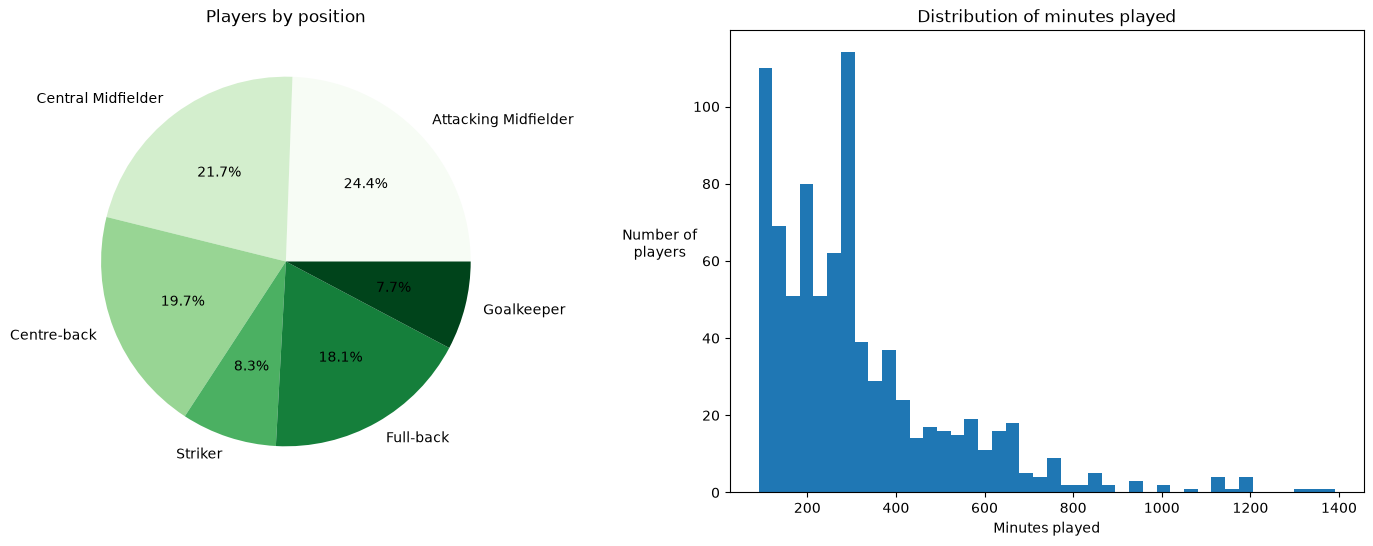

In [9]:
# charts
import matplotlib.pyplot as plt
fig, (positions_ax, minutes_ax) = plt.subplots(1, 2, figsize = (18, 6))

position_counts = dataset_final['target_position'].value_counts(normalize=True, sort=False)
position_counts.plot.pie(ax = positions_ax, autopct = "%1.1f%%", cmap = 'Greens')
positions_ax.set_ylabel('')
positions_ax.set_title('Players by position')

minutes_ax.hist(dataset_final['minutes_played'], bins = 42)
minutes_ax.set_xlabel('Minutes played')
minutes_ax.set_ylabel('Number of\nplayers', rotation = 0, labelpad = 24)
minutes_ax.set_title('Distribution of minutes played')

plt.show()

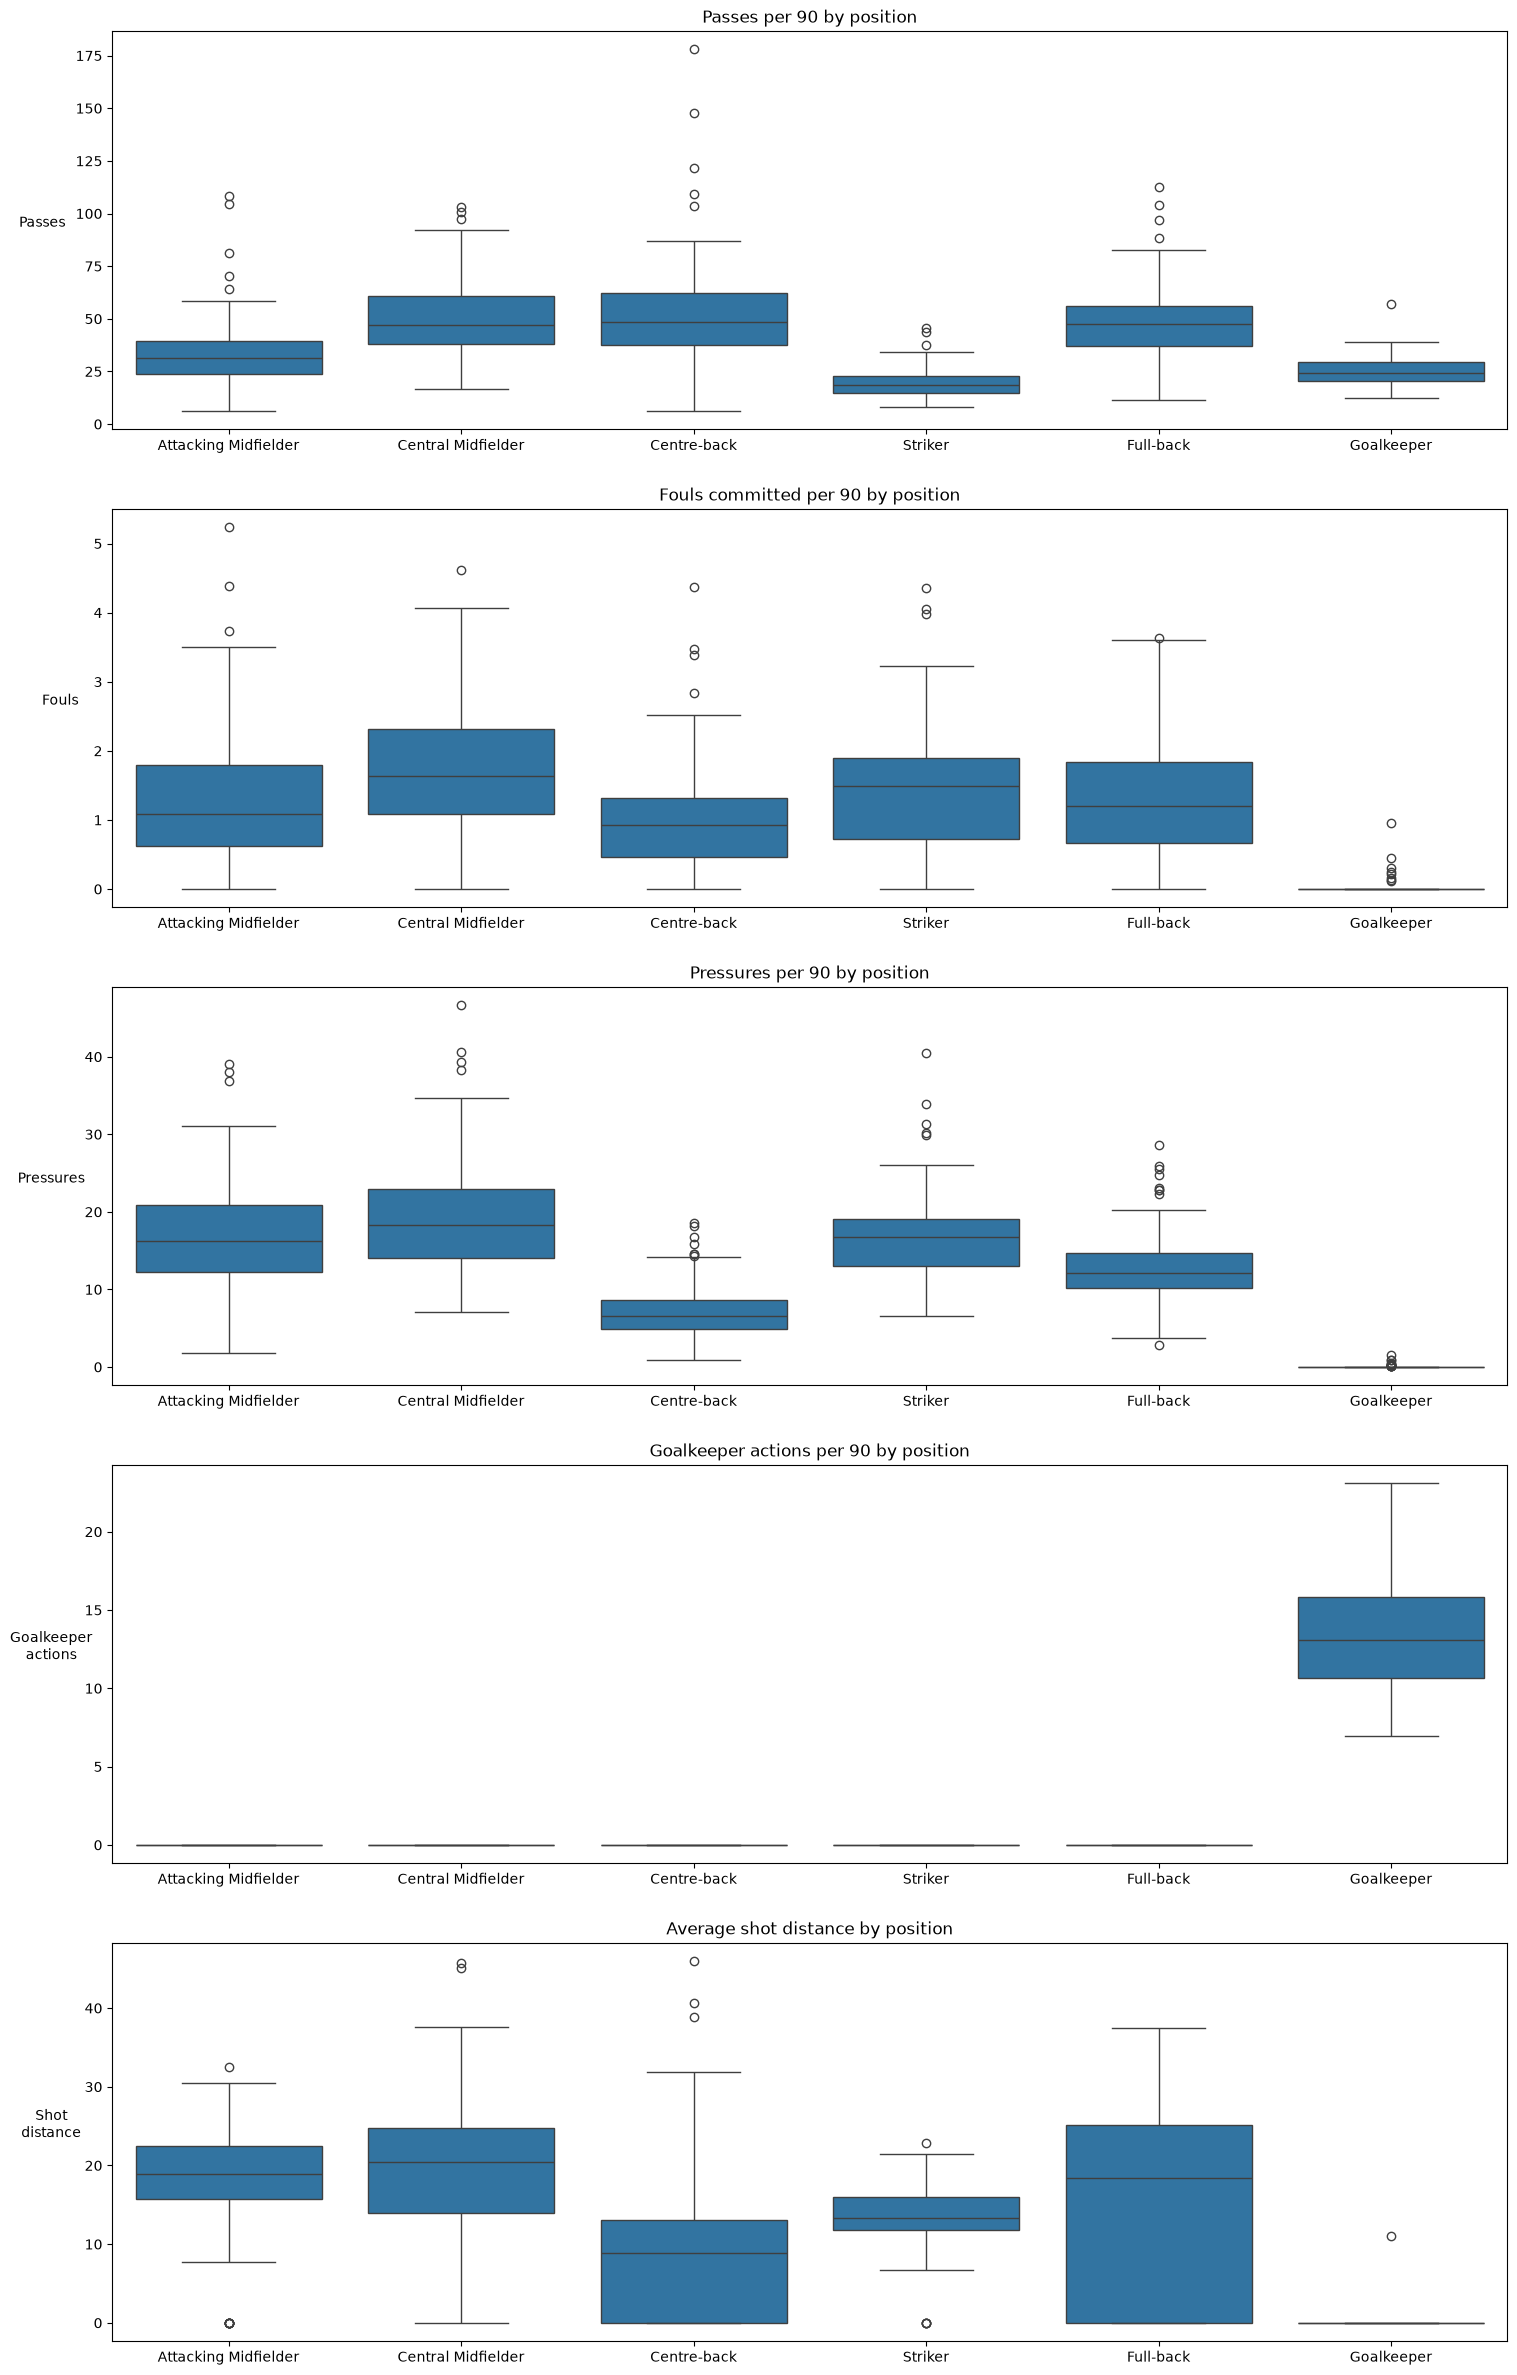

In [10]:
# boxplots
import seaborn as sns
fig, (passes_ax, fouls_ax, pressure_ax, keeper_ax, shot_distance_ax) = plt.subplots(5, figsize = (18, 30))

sns.boxplot(x = 'target_position', y = 'Pass_p90', data = dataset_final, ax = passes_ax)
passes_ax.set_title('Passes per 90 by position')
passes_ax.set_xlabel('')
passes_ax.set_ylabel('Passes', rotation = 0, labelpad = 24)

sns.boxplot(x = 'target_position', y = 'Foul Committed_p90', data = dataset_final, ax = fouls_ax)
fouls_ax.set_title('Fouls committed per 90 by position')
fouls_ax.set_xlabel('')
fouls_ax.set_ylabel('Fouls', rotation = 0, labelpad = 24)

sns.boxplot(x = 'target_position', y = 'Pressure_p90', data = dataset_final, ax = pressure_ax)
pressure_ax.set_title('Pressures per 90 by position')
pressure_ax.set_xlabel('')
pressure_ax.set_ylabel('Pressures', rotation = 0, labelpad = 24)

sns.boxplot(x = 'target_position', y = 'Goal Keeper_p90', data = dataset_final, ax = keeper_ax)
keeper_ax.set_title('Goalkeeper actions per 90 by position')
keeper_ax.set_xlabel('')
keeper_ax.set_ylabel('Goalkeeper\nactions', rotation = 0, labelpad = 24)

sns.boxplot(x = 'target_position', y = 'avg_shot_distance', data = dataset_final, ax = shot_distance_ax)
shot_distance_ax.set_title('Average shot distance by position')
shot_distance_ax.set_xlabel('')
shot_distance_ax.set_ylabel('Shot\ndistance', rotation = 0, labelpad = 24)

plt.show()

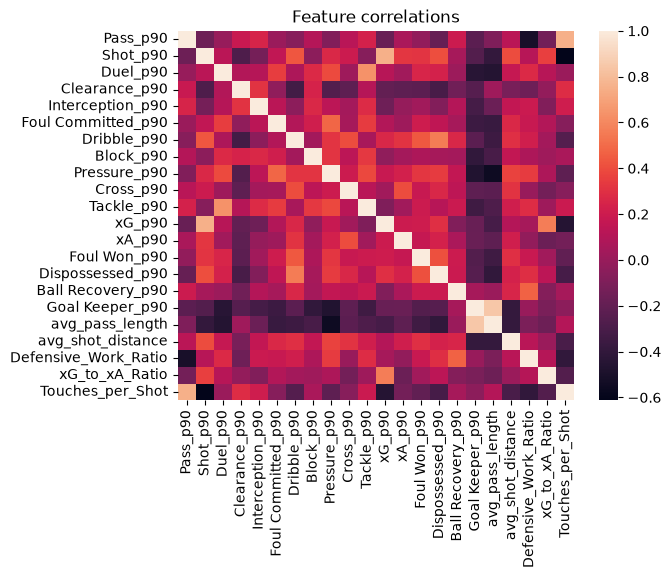

In [11]:
# heatmap
feature_columns = [
    'Pass_p90', 'Shot_p90', 'Duel_p90', 'Clearance_p90', 'Interception_p90',
    'Foul Committed_p90', 'Dribble_p90', 'Block_p90',
    'Pressure_p90',
    'Cross_p90', 'Tackle_p90', 'xG_p90', 'xA_p90',
    'Foul Won_p90', 'Dispossessed_p90', 'Ball Recovery_p90',
    'Goal Keeper_p90',
    'avg_pass_length', 'avg_shot_distance',
    'Defensive_Work_Ratio', 'xG_to_xA_Ratio', 'Touches_per_Shot'
]
correlation = dataset_final[feature_columns].corr()
sns.heatmap(data = correlation)
plt.title('Feature correlations')
plt.show()

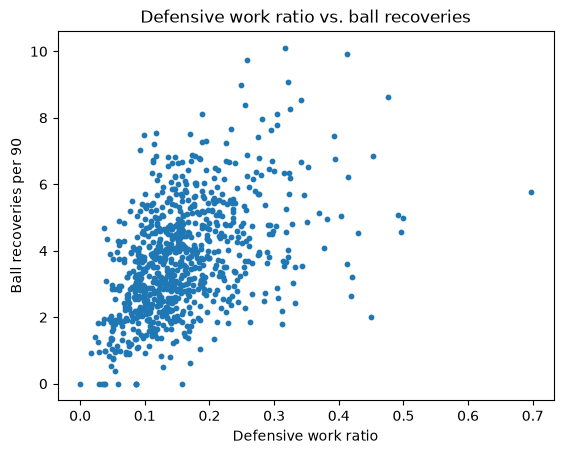

In [12]:
# scatter plot
plt.scatter(x = dataset_final['Defensive_Work_Ratio'], y = dataset_final['Ball Recovery_p90'], s = 10)
plt.title('Defensive work ratio vs. ball recoveries')
plt.xlabel('Defensive work ratio')
plt.ylabel('Ball recoveries per 90')
plt.show()

In [13]:
# train/test split (uses feature_columns from the heatmap cell)
from sklearn.model_selection import train_test_split

X = dataset_final[feature_columns]
y = dataset_final['target_position']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

train_dataset = dataset_final.loc[X_train.index]
test_dataset = dataset_final.loc[X_test.index]

train_dataset.to_csv('train.csv', index=False)
test_dataset.to_csv('test.csv', index=False)

In [14]:
X_train.describe()

,Pass_p90,Shot_p90,Duel_p90,Clearance_p90,Interception_p90,Foul Committed_p90,Dribble_p90,Block_p90,Pressure_p90,Cross_p90,...,xA_p90,Foul Won_p90,Dispossessed_p90,Ball Recovery_p90,Goal Keeper_p90,avg_pass_length,avg_shot_distance,Defensive_Work_Ratio,xG_to_xA_Ratio,Touches_per_Shot
count,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,...,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000,587.000000
mean,41.274293,1.012538,2.548586,1.531073,0.877394,1.231363,1.206695,1.506150,13.394821,1.023731,...,0.069506,1.163373,0.891227,3.628944,1.089932,21.309460,14.340465,0.154824,3.385125,28.216075
std,18.697013,1.082118,1.639881,1.638758,0.769133,0.954695,1.392273,1.041124,7.779021,1.252216,...,0.114231,1.016168,0.987088,1.646664,3.888783,7.563429,10.404378,0.076153,7.678434,17.685192
min,6.310000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,10.880970,0.000000,0.000000,0.000000,3.512287
25%,27.420000,0.000000,1.535000,0.270000,0.270000,0.540000,0.000000,0.770000,8.010000,0.000000,...,0.000000,0.395000,0.000000,2.500000,0.000000,17.221920,0.000000,0.101916,0.000000,15.236164
50%,38.540000,0.720000,2.410000,0.970000,0.770000,1.070000,0.770000,1.440000,12.740000,0.600000,...,0.030000,0.930000,0.610000,3.530000,0.000000,19.495158,15.454352,0.139949,0.769231,24.777778
75%,51.930000,1.545000,3.500000,2.330000,1.315000,1.800000,1.810000,2.130000,18.255000,1.650000,...,0.090000,1.710000,1.380000,4.650000,0.000000,22.384989,22.148385,0.190432,3.250000,36.773235
max,147.610000,7.740000,11.610000,7.940000,4.170000,5.240000,7.910000,5.450000,40.560000,8.180000,...,1.030000,5.970000,6.080000,10.110000,23.120000,65.250049,46.010868,0.490872,74.000000,122.598361


In [15]:
X_test.describe()

,Pass_p90,Shot_p90,Duel_p90,Clearance_p90,Interception_p90,Foul Committed_p90,Dribble_p90,Block_p90,Pressure_p90,Cross_p90,...,xA_p90,Foul Won_p90,Dispossessed_p90,Ball Recovery_p90,Goal Keeper_p90,avg_pass_length,avg_shot_distance,Defensive_Work_Ratio,xG_to_xA_Ratio,Touches_per_Shot
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,...,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,42.057460,1.091468,2.584365,1.518254,0.858849,1.260238,1.396270,1.600040,13.597460,1.027817,...,0.065238,1.107817,0.886667,3.927341,0.990278,21.150521,14.395312,0.165433,4.352513,28.124256
std,20.882863,1.085400,1.577630,1.704449,0.742007,0.882369,1.745215,1.072206,8.149933,1.407174,...,0.099326,1.065974,1.006076,1.686999,3.650970,7.867303,9.485838,0.088629,11.435110,19.383852
min,6.160000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,10.722923,0.000000,0.029028,0.000000,1.942857
25%,26.385000,0.287500,1.572500,0.132500,0.227500,0.630000,0.260000,0.867500,8.275000,0.000000,...,0.000000,0.320000,0.000000,2.725000,0.000000,17.200880,7.913908,0.107561,0.073413,14.775987
50%,40.175000,0.715000,2.480000,0.940000,0.790000,1.190000,0.865000,1.545000,13.045000,0.475000,...,0.030000,0.935000,0.615000,3.870000,0.000000,19.369211,15.672926,0.152263,1.000000,24.854316
75%,54.382500,1.735000,3.492500,2.392500,1.310000,1.880000,1.825000,2.230000,18.000000,1.540000,...,0.100000,1.640000,1.347500,4.985000,0.000000,22.750409,21.327300,0.197724,3.711230,37.813911
max,178.120000,4.950000,8.000000,8.260000,3.300000,4.380000,10.880000,5.810000,46.680000,11.520000,...,1.000000,8.920000,5.580000,9.920000,21.980000,63.719163,37.202150,0.697396,94.000000,179.060000


                      precision    recall  f1-score   support

Attacking Midfielder       0.69      0.61      0.65        62
  Central Midfielder       0.76      0.71      0.74        55
         Centre-back       0.90      0.94      0.92        49
           Full-back       0.80      0.76      0.78        46
          Goalkeeper       1.00      1.00      1.00        19
             Striker       0.53      0.81      0.64        21

            accuracy                           0.77       252
           macro avg       0.78      0.81      0.79       252
        weighted avg       0.78      0.77      0.77       252

Accuracy: 0.7698
Precision: 0.7771
Recall: 0.7698
F1-Score: 0.7701



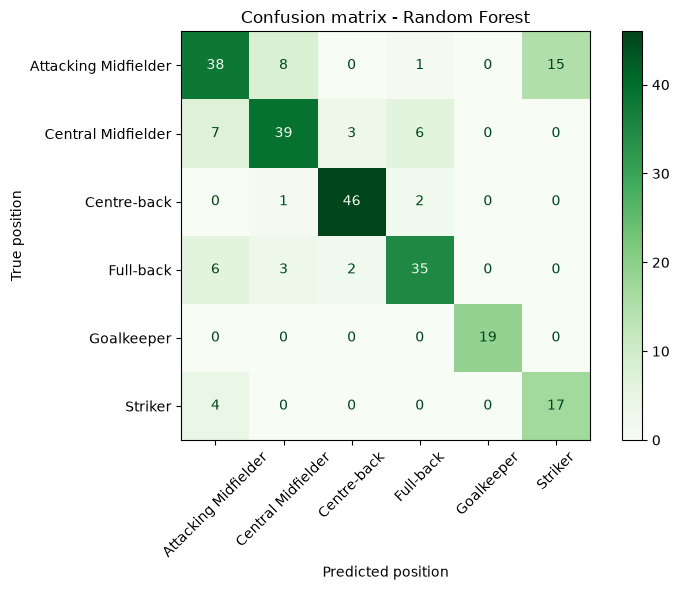

In [16]:
# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
RF = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=2, random_state=69 ,class_weight='balanced', max_features=5)
RF.fit(X_train, y_train)
y_pred_RF = RF.predict(X_test)
accuracy_RF = accuracy_score(y_test, y_pred_RF)
precision_RF = precision_score(y_test, y_pred_RF, average='weighted', zero_division=0)
recall_RF = recall_score(y_test, y_pred_RF, average='weighted', zero_division=0)
f1_RF = f1_score(y_test, y_pred_RF, average='weighted', zero_division=0)

joblib.dump(RF, 'Position_Predictor.pkl')


print(classification_report(y_test, y_pred_RF))
print(f"Accuracy: {accuracy_RF:.4f}")
print(f"Precision: {precision_RF:.4f}")
print(f"Recall: {recall_RF:.4f}")
print(f"F1-Score: {f1_RF:.4f}\n")

cm_RF = confusion_matrix(y_test, y_pred_RF, labels=RF.classes_)
disp_RF = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels=RF.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp_RF.plot(cmap='Greens', ax=ax, xticks_rotation=45)
plt.title('Confusion matrix - Random Forest')
plt.xlabel('Predicted position')
plt.ylabel('True position')
plt.tight_layout()
plt.show()

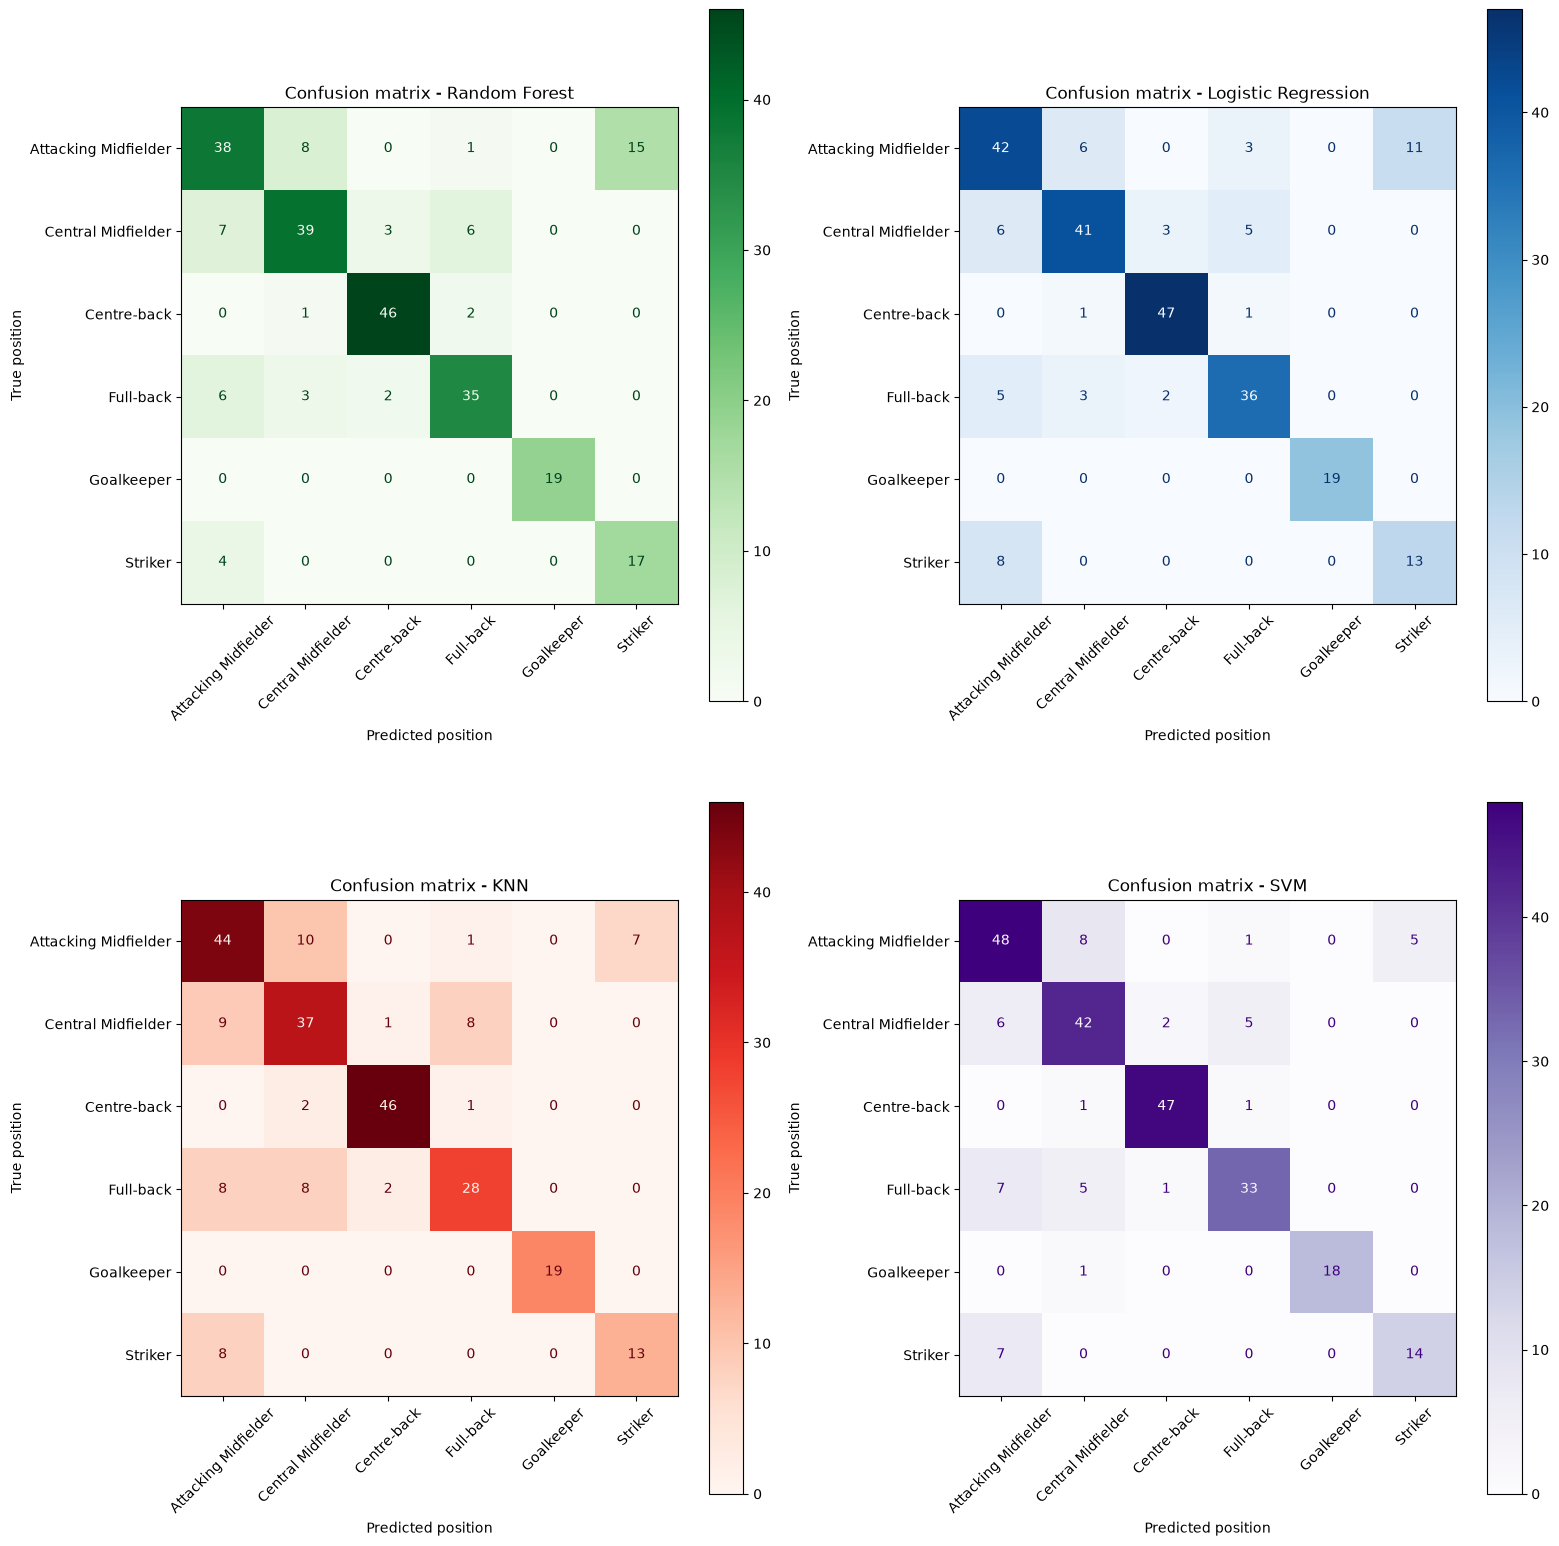

In [17]:
# comparison of 4 models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# the random forest from the previous cell doesn't need scaling
scale = StandardScaler()
x_train_scaled = scale.fit_transform(X_train)
x_test_scaled = scale.transform(X_test)

train_scaled_df = pd.DataFrame(x_train_scaled)
test_scaled_df = pd.DataFrame(x_test_scaled)
train_scaled_df.to_csv('train_scaled.csv', index=False)
test_scaled_df.to_csv('test_scaled.csv', index=False)

# Logistic regression
LR = LogisticRegression(solver = 'lbfgs', random_state = 42)
LR.fit(x_train_scaled, y_train)

y_pred_LR = LR.predict(x_test_scaled)
accuracy_LR = accuracy_score(y_test, y_pred_LR)
precision_LR = precision_score(y_test, y_pred_LR, average='weighted', zero_division=0)
f1_LR = f1_score(y_test, y_pred_LR, average='weighted', zero_division=0)

# KNN
KNN = KNeighborsClassifier(n_neighbors = 5)
KNN.fit(x_train_scaled, y_train)

y_pred_KNN = KNN.predict(x_test_scaled)
accuracy_KNN = accuracy_score(y_test, y_pred_KNN)
precision_KNN = precision_score(y_test, y_pred_KNN, average='weighted', zero_division=0)
f1_KNN = f1_score(y_test, y_pred_KNN, average='weighted', zero_division=0)

#SVM
SVM = SVC(kernel = 'rbf', C = 1, gamma = 'scale', random_state = 42)
SVM.fit(x_train_scaled, y_train)

y_pred_SVM = SVM.predict(x_test_scaled)
accuracy_SVM = accuracy_score(y_test, y_pred_SVM)
precision_SVM = precision_score(y_test, y_pred_SVM, average='weighted', zero_division=0)
f1_SVM = f1_score(y_test, y_pred_SVM, average='weighted', zero_division=0)

# confusion matrices
cm_LR = confusion_matrix(y_test, y_pred_LR, labels=LR.classes_)
disp_LR = ConfusionMatrixDisplay(confusion_matrix=cm_LR, display_labels=LR.classes_)

cm_KNN = confusion_matrix(y_test, y_pred_KNN, labels=KNN.classes_)
disp_KNN = ConfusionMatrixDisplay(confusion_matrix=cm_KNN, display_labels=KNN.classes_)

cm_SVM = confusion_matrix(y_test, y_pred_SVM, labels=SVM.classes_)
disp_SVM = ConfusionMatrixDisplay(confusion_matrix=cm_SVM, display_labels=SVM.classes_)

# display
cm_figure, ((rf_ax, lr_ax), (knn_ax, svm_ax)) = plt.subplots(2, 2, figsize = (16, 16))

for disp, ax, cmap, title in [
    (disp_RF, rf_ax, 'Greens', 'Random Forest'),
    (disp_LR, lr_ax, 'Blues', 'Logistic Regression'),
    (disp_KNN, knn_ax, 'Reds', 'KNN'),
    (disp_SVM, svm_ax, 'Purples', 'SVM'),
]:
  disp.plot(cmap = cmap, ax = ax, xticks_rotation = 45)
  ax.set_title(f'Confusion matrix - {title}')
  ax.set_xlabel('Predicted position')
  ax.set_ylabel('True position')

plt.tight_layout()
plt.show()

In [18]:
# performance on the test set
from tabulate import tabulate

results = [
    ['RF', accuracy_RF, f1_RF, precision_RF],
    ['LR', accuracy_LR, f1_LR, precision_LR],
    ['KNN', accuracy_KNN, f1_KNN, precision_KNN],
    ['SVM', accuracy_SVM, f1_SVM, precision_SVM]
]

print(tabulate(results, headers = ['Model', 'Accuracy', 'F1 score', 'Precision'], tablefmt = "grid"))

+---------+------------+------------+-------------+
| Model   |   Accuracy |   F1 score |   Precision |
+=========+============+============+=============+
| RF      |   0.769841 |   0.770138 |    0.777137 |
+---------+------------+------------+-------------+
| LR      |   0.785714 |   0.7858   |    0.787173 |
+---------+------------+------------+-------------+
| KNN     |   0.742063 |   0.741952 |    0.74517  |
+---------+------------+------------+-------------+
| SVM     |   0.801587 |   0.80178  |    0.804662 |
+---------+------------+------------+-------------+


In [19]:
# 5-fold cross-validation on the training set only
# StandardScaler is inside a Pipeline, so it is fitted only on each fold's training part
# (otherwise information from the validation fold leaks into the scaling)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# baseline: always predict the most common position
baseline = DummyClassifier(strategy='most_frequent')
cv_models = {
    'Baseline': baseline,
    'RF': RF,
    'LR': make_pipeline(StandardScaler(), LR),
    'KNN': make_pipeline(StandardScaler(), KNN),
    'SVM': make_pipeline(StandardScaler(), SVM),
}
accuracy_baseline = baseline.fit(X_train, y_train).score(X_test, y_test)
test_accuracy = {'Baseline': accuracy_baseline, 'RF': accuracy_RF, 'LR': accuracy_LR, 'KNN': accuracy_KNN, 'SVM': accuracy_SVM}

cv_results = []
for name, model in cv_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=['accuracy', 'f1_weighted'], n_jobs=-1)
    cv_results.append([
        name,
        f"{scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}",
        f"{scores['test_f1_weighted'].mean():.3f} ± {scores['test_f1_weighted'].std():.3f}",
        f"{test_accuracy[name]:.3f}",
    ])

print(tabulate(cv_results, headers=['Model', 'CV accuracy', 'CV F1 score', 'Test accuracy'], tablefmt='grid', disable_numparse=True))

+----------+---------------+---------------+-----------------+
| Model    | CV accuracy   | CV F1 score   | Test accuracy   |
+==========+===============+===============+=================+
| Baseline | 0.244 ± 0.004 | 0.095 ± 0.003 | 0.246           |
+----------+---------------+---------------+-----------------+
| RF       | 0.784 ± 0.035 | 0.782 ± 0.037 | 0.770           |
+----------+---------------+---------------+-----------------+
| LR       | 0.816 ± 0.032 | 0.815 ± 0.034 | 0.786           |
+----------+---------------+---------------+-----------------+
| KNN      | 0.717 ± 0.040 | 0.712 ± 0.042 | 0.742           |
+----------+---------------+---------------+-----------------+
| SVM      | 0.768 ± 0.049 | 0.763 ± 0.052 | 0.802           |
+----------+---------------+---------------+-----------------+


Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 3, 'min_samples_leaf': 1}
CV accuracy (tuned RF): 0.802 ± 0.022
Test accuracy (tuned RF): 0.782
Test F1 score (tuned RF): 0.782

                      precision    recall  f1-score   support

Attacking Midfielder       0.73      0.61      0.67        62
  Central Midfielder       0.79      0.75      0.77        55
         Centre-back       0.90      0.94      0.92        49
           Full-back       0.80      0.78      0.79        46
          Goalkeeper       1.00      1.00      1.00        19
             Striker       0.52      0.81      0.63        21

            accuracy                           0.78       252
           macro avg       0.79      0.81      0.80       252
        weighted avg       0.79      0.78      0.78       252



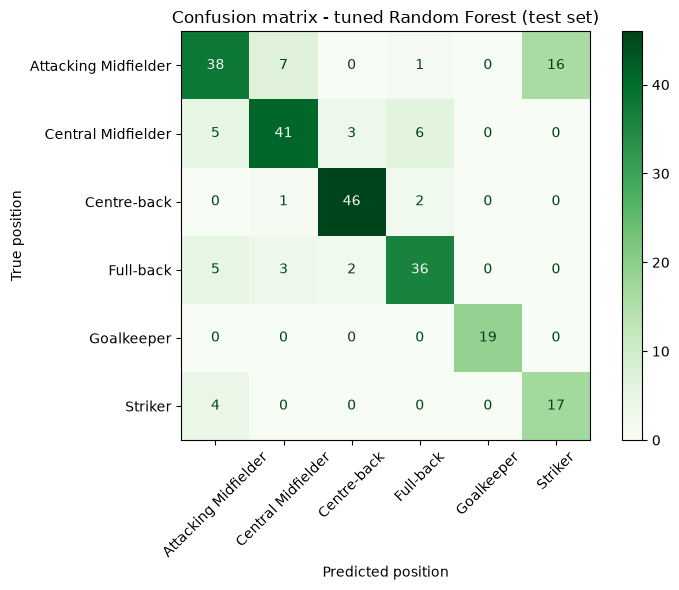

In [20]:
# hyperparameter search for the random forest with GridSearchCV
# uses only the training set (same 5 folds as above);
# the test set is used once, at the end, for the chosen model
from sklearn.model_selection import GridSearchCV

RF_grid = {
    'max_depth': [None, 5, 10, 15],
    'max_features': ['sqrt', 3, 5, 8],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None],
}
RF_search = GridSearchCV(
    RandomForestClassifier(n_estimators=500, random_state=69),
    RF_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
)
RF_search.fit(X_train, y_train)

RF_search_results = pd.DataFrame(RF_search.cv_results_)
RF_tuned_std = RF_search_results.loc[RF_search.best_index_, 'std_test_score']
print('Best parameters:', RF_search.best_params_)
print(f'CV accuracy (tuned RF): {RF_search.best_score_:.3f} ± {RF_tuned_std:.3f}')

RF_tuned = RF_search.best_estimator_
y_pred_RF_tuned = RF_tuned.predict(X_test)
print(f'Test accuracy (tuned RF): {accuracy_score(y_test, y_pred_RF_tuned):.3f}')
print(f'Test F1 score (tuned RF): {f1_score(y_test, y_pred_RF_tuned, average="weighted", zero_division=0):.3f}\n')
print(classification_report(y_test, y_pred_RF_tuned))

# the tuned model replaces the saved one, so the app below uses it
joblib.dump(RF_tuned, 'Position_Predictor.pkl')

disp_RF_tuned = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_RF_tuned, labels=RF_tuned.classes_, cmap='Greens', xticks_rotation=45)
disp_RF_tuned.figure_.set_size_inches(8, 6)
plt.title('Confusion matrix - tuned Random Forest (test set)')
plt.xlabel('Predicted position')
plt.ylabel('True position')
plt.tight_layout()
plt.show()

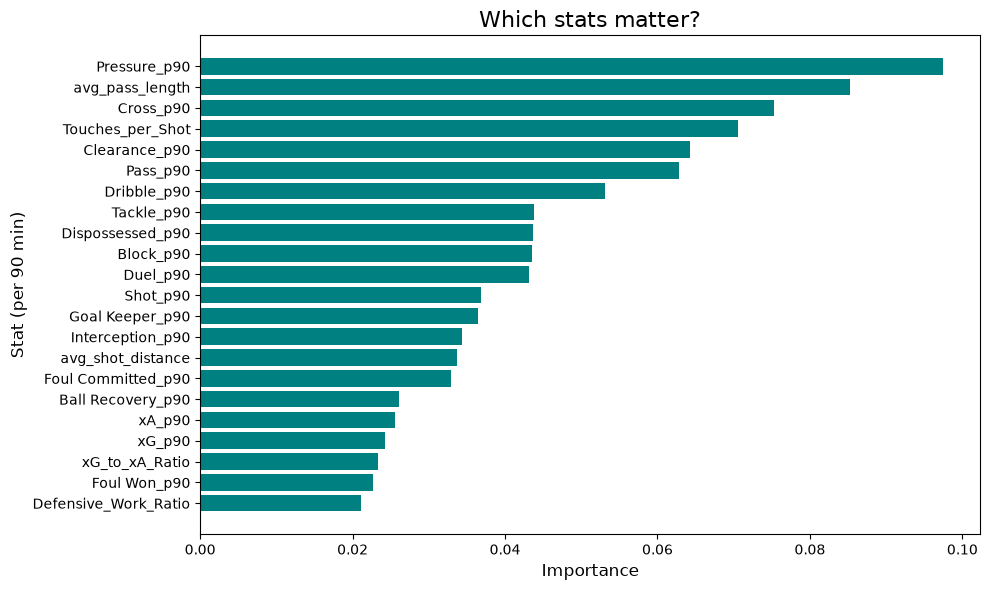

In [21]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': RF_tuned.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')

plt.title('Which stats matter?', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Stat (per 90 min)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# interactive app
import gradio as gr
import pandas as pd
import joblib

loaded_model = joblib.load('Position_Predictor.pkl')

def predict_position(p, s, d, c, i, f, dr, b, pr, cr, t, xg, xa, fw, dp, br, gk, apl, asd):
    xGxA = xg / (xa + 0.01)
    dwr = (t + i + br) / (p + 1)
    tps = (p + dr + d) / (s + 1)
    player_data = pd.DataFrame({
        'Pass_p90': [p],
        'Shot_p90': [s],
        'Duel_p90': [d],
        'Clearance_p90': [c],
        'Interception_p90': [i],
        'Foul Committed_p90': [f],
        'Dribble_p90': [dr],
        'Block_p90': [b],
        'Pressure_p90': [pr],
        'Cross_p90': [cr],
        'Tackle_p90': [t],
        'xG_p90': [xg],
        'xA_p90': [xa],
        'Foul Won_p90': [fw],
        'Dispossessed_p90': [dp],
        'Ball Recovery_p90': [br],
        'Goal Keeper_p90': [gk],
        'avg_pass_length': [apl],
        'avg_shot_distance': [asd],
        'Defensive_Work_Ratio': [dwr],
        'xG_to_xA_Ratio': [xGxA],
        'Touches_per_Shot': [tps]
    })

    probabilities = loaded_model.predict_proba(player_data)[0]
    classes = loaded_model.classes_
    class_probabilities = {str(classes[idx]): float(probabilities[idx]) for idx in range(len(classes))}

    return class_probabilities, round(dwr, 2), round(xGxA, 2), round(tps, 2)


app_inputs = [
    gr.Slider(minimum=0, maximum=150, step=0.1, label="Passes per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Shots per 90"),
    gr.Slider(minimum=0, maximum=10, step=0.05, label="Duels per 90"),
    gr.Slider(minimum=0, maximum=8, step=0.01, label="Clearances per 90"),
    gr.Slider(minimum=0, maximum=4, step=0.01, label="Interceptions per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Fouls committed per 90"),
    gr.Slider(minimum=0, maximum=10, step=0.01, label="Dribbles per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Blocks per 90"),
    gr.Slider(minimum=0, maximum=40, step=0.1, label="Pressures per 90"),
    gr.Slider(minimum=0, maximum=10, step=0.01, label="Crosses per 90"),
    gr.Slider(minimum=0, maximum=7, step=0.01, label="Tackles per 90"),
    gr.Slider(minimum=0, maximum=1.5, step=0.01, label="xG per 90"),
    gr.Slider(minimum=0, maximum=1, step=0.01, label="xA per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Fouls won per 90"),
    gr.Slider(minimum=0, maximum=5, step=0.01, label="Times dispossessed per 90"),
    gr.Slider(minimum=0, maximum=10, step=0.01, label="Ball recoveries per 90"),
    gr.Slider(minimum=0, maximum=20, step=0.01, label="Goalkeeper actions per 90"),
    gr.Number(label="Average pass length", value=20),
    gr.Number(label="Average shot distance", value=16),
]

app_outputs = [
    gr.Label(num_top_classes=3, label="Predicted position"),
    gr.Number(label="Defensive Work Ratio"),
    gr.Number(label="xG to xA Ratio"),
    gr.Number(label="Touches per Shot")
]

app = gr.Interface(
    fn=predict_position,
    inputs=app_inputs,
    outputs=app_outputs,
    title="Player Position Predictor",
    theme="default"
)

app.launch()

In [ ]:
with gr.Blocks() as charts_app:
  gr.Markdown('# Confusion matrices')
  plot_output = gr.Plot(value = cm_figure)
charts_app.launch()